# Deep Learning Experiment 6: Time-Series Prediction with BiRNN and Feedforward NN

Data head:


,Passengers
0,112
1,118
2,132
3,129
4,121


Scaled data shape: (144, 1)
X_train shape: (107, 10, 1)
y_train shape: (107, 1)
X_test shape: (27, 10, 1)
y_test shape: (27, 1)
X_train_tensor shape: torch.Size([107, 10, 1])
y_train_tensor shape: torch.Size([107, 1])

Training BiRNN...
Epoch 20/100, Loss: 0.00247
Epoch 40/100, Loss: 0.00194
Epoch 60/100, Loss: 0.00217
Epoch 80/100, Loss: 0.00185
Epoch 100/100, Loss: 0.00180

Training FeedforwardNN...
Epoch 20/100, Loss: 0.00364
Epoch 40/100, Loss: 0.00220
Epoch 60/100, Loss: 0.00235
Epoch 80/100, Loss: 0.00140
Epoch 100/100, Loss: 0.00098

Prediction complete for both models.


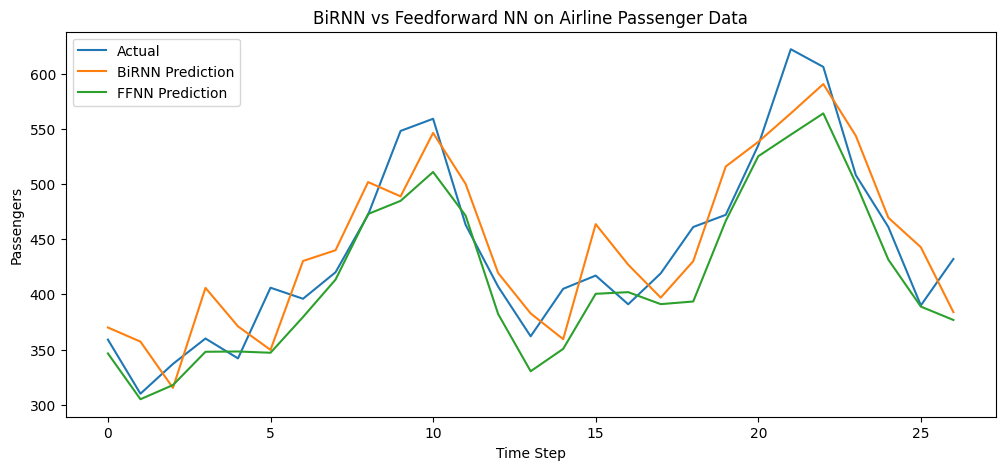


BiRNN MSE: 1331.759
FFNN MSE: 1225.498


In [2]:
# Step 1: Import Necessary Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Step 2: Data Preparation
url='https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/monthly-airline-passengers.csv'
df = pd.read_csv(url, usecols=[1])
data = df.values.astype('float32')
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

print("Data head:")
display(df.head())
print("Scaled data shape:", data_scaled.shape)

# Step 3: Create Sequences for Time-Series Prediction
SEQ_LENGTH = 10
X = np.array([data_scaled[i:i+SEQ_LENGTH] for i in range(len(data_scaled) - SEQ_LENGTH)])
y = np.array([data_scaled[i + SEQ_LENGTH] for i in range(len(data_scaled) - SEQ_LENGTH)])

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Step 4: Prepare PyTorch Datasets and Loaders
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=1)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

# Step 5: Define BiRNN and Feedforward Models
class BiRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(BiRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class FeedforwardNN(nn.Module):
    def __init__(self, input_size):
        super(FeedforwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(self.relu(self.fc1(x)))

# Step 6: Define Training and Evaluation Functions
def train_model(model, loader, epochs=100):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    model.train()
    print(f"\nTraining {model.__class__.__name__}...")
    for epoch in range(epochs):
        loss_epoch = 0
        for seqs, targets in loader:
            optimizer.zero_grad()
            outputs = model(seqs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            loss_epoch += loss.item()
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_epoch / len(loader):.5f}")

def evaluate_model(model, X):
    model.eval()
    with torch.no_grad():
        return model(X).numpy()

# Step 7: Train and Predict with Both Models
birnn = BiRNN()
train_model(birnn, train_loader)

ffnn = FeedforwardNN(input_size=SEQ_LENGTH)
train_model(ffnn, train_loader)

pred_birnn = evaluate_model(birnn, X_test_tensor)
pred_ffnn = evaluate_model(ffnn, X_test_tensor)

print("\nPrediction complete for both models.")

# Step 8: Inverse Transform and Plot Results
pred_birnn_inv = scaler.inverse_transform(pred_birnn)
pred_ffnn_inv = scaler.inverse_transform(pred_ffnn)
y_test_inv = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='Actual')
plt.plot(pred_birnn_inv, label='BiRNN Prediction')
plt.plot(pred_ffnn_inv, label='FFNN Prediction')
plt.legend()
plt.title('BiRNN vs Feedforward NN on Airline Passenger Data')
plt.xlabel('Time Step')
plt.ylabel('Passengers')
plt.show()

mse_birnn = mean_squared_error(y_test_inv, pred_birnn_inv)
mse_ffnn = mean_squared_error(y_test_inv, pred_ffnn_inv)
print(f"\nBiRNN MSE: {mse_birnn:.3f}")
print(f"FFNN MSE: {mse_ffnn:.3f}")